# Análisis exploratorio del costo unitario de transformación

**Artículo de análisis aplicado**  
**Área:** costos de producción y analítica industrial

## Resumen

Se caracteriza la distribución de `costo_transformacion` y su relación con variables de escala, consumo de insumos, duración y configuración del proceso. El análisis comprende 404 órdenes de producción y combina estadísticos descriptivos, correlaciones de Spearman, suavizado LOWESS y comparaciones por grupos. El costo presenta asimetría positiva y variabilidad considerable. El costo de insumos y la duración muestran las asociaciones marginales positivas más altas con el objetivo; el volumen del lote presenta una asociación negativa débil. También se observan diferencias descriptivas entre equipos y modalidades. Estos patrones justifican comparar modelos que representen no linealidad y heterogeneidad, pero no permiten atribuir efectos causales.

**Palabras clave:** costos unitarios, producción, análisis exploratorio, regresión, LOWESS.

## 1. Pregunta y objetivo

**Pregunta:** ¿Qué distribución presenta el costo unitario de transformación y qué características de las órdenes muestran asociación descriptiva con él?

El objetivo es evaluar la estructura estadística del costo y orientar la construcción de modelos predictivos. La unidad de análisis es la orden de producción; la variable respuesta es `costo_transformacion`. Las asociaciones reportadas son marginales y no deben interpretarse como efectos causales.

## 2. Datos y métodos

El archivo analizado contiene registros mensuales de órdenes de producción. Se resumen la completitud y la estructura de los datos; se describen la respuesta y las variables cuantitativas mediante medidas de posición y dispersión; se estima la asociación monotónica mediante rho de Spearman; se utilizan curvas LOWESS para explorar formas no lineales; y se comparan distribuciones por categorías operativas.

Las observaciones se analizan como registros tabulares. Los resúmenes mensuales son descriptivos: por sí solos no constituyen un análisis de series temporales ni permiten pronosticar periodos futuros.

Como referencia predictiva se ajusta una regresión lineal con penalización Ridge. El desempeño se estima mediante validación cruzada repetida y mediante particiones que mantienen todos los registros de cada producto en un solo pliegue. En ambos casos se compara con un predictor de referencia que asigna a cada observación la media del costo del conjunto de entrenamiento.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

candidate_paths = [
    Path.cwd() / "data_costos.csv",
    Path("C:/Users/Work/OneDrive - Keywest Strategic Systems Inc/Documents/Maestria/Machine Learning/Project/data_costos.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data_costos.csv. Coloca el archivo junto a este notebook.")

df = pd.read_csv(DATA_PATH, sep=";")
TARGET = "costo_transformacion"
print(f"Archivo analizado: {DATA_PATH.name}")
print(f"Dimensiones: {df.shape[0]:,} órdenes por {df.shape[1]} variables")

Archivo analizado: data_costos.csv
Dimensiones: 404 órdenes por 16 variables


## 3. Resultados

### 3.1 Completitud y estructura

In [2]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes_n": df.isna().sum(),
    "faltantes_pct": (100 * df.isna().mean()).round(1),
    "valores_distintos": df.nunique(dropna=True),
})
display(resumen_calidad)
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Identificadores de orden únicos: {df['id_orden'].nunique()} de {len(df)}")
print(f"Códigos de producto: {df['codigo_producto'].nunique()}")
print(f"Cobertura: {df['periodo'].min()} a {df['periodo'].max()} ({df['periodo'].nunique()} periodos)")

,tipo,faltantes_n,faltantes_pct,valores_distintos
periodo,int64,0,0.0,15
codigo_producto,object,0,0.0,125
id_orden,int64,0,0.0,404
volumen_lote,float64,0,0.0,287
costo_transformacion,float64,0,0.0,398
costo_insumo,float64,0,0.0,393
equipo_id,object,0,0.0,12
tipo_equipo,object,0,0.0,4
categoria_producto,int64,0,0.0,7
num_insumos,int64,0,0.0,3


Filas duplicadas exactas: 0
Identificadores de orden únicos: 404 de 404
Códigos de producto: 125
Cobertura: 202501 a 202603 (15 periodos)


**Interpretación.** El extracto contiene 404 órdenes, sin duplicados exactos y con identificadores de orden únicos. Hay 125 códigos de producto, muchos con pocas observaciones. La respuesta está completa; los faltantes se concentran en las etiquetas de insumos, por lo que deben interpretarse según la estructura de la receta y no imputarse automáticamente como si fueran ausencias aleatorias.

In [3]:
revision_insumos = (df.groupby("num_insumos", dropna=False)
    .agg(ordenes=(TARGET, "size"),
         faltantes_insumo_1=("insumo_1", lambda s: s.isna().sum()),
         faltantes_insumo_2=("insumo_2", lambda s: s.isna().sum()))
    .reset_index())
display(revision_insumos)

,num_insumos,ordenes,faltantes_insumo_1,faltantes_insumo_2
0,0,8,8,8
1,1,271,0,271
2,2,125,0,0


**Interpretación de la tabla.** Las 8 órdenes con `num_insumos = 0` carecen de `insumo_1`; las 279 órdenes con cero o un insumo carecen de `insumo_2`. El patrón es coherente con campos estructuralmente no aplicables cuando el insumo no existe. Conviene codificar esa ausencia explícitamente como “sin insumo” al modelar, en vez de reemplazarla por una categoría frecuente.

### 3.2 Distribución del costo de transformación

In [4]:
y = pd.to_numeric(df[TARGET], errors="coerce").dropna()
resumen_objetivo = pd.DataFrame({
    "estadistico": ["n", "media", "desviación estándar", "mínimo", "Q1", "mediana", "Q3", "P95", "P99", "máximo", "asimetría", "ceros"],
    "valor": [len(y), y.mean(), y.std(ddof=1), y.min(), y.quantile(.25), y.median(), y.quantile(.75),
              y.quantile(.95), y.quantile(.99), y.max(), y.skew(), int((y == 0).sum())],
})
resumen_objetivo["valor"] = resumen_objetivo["valor"].round(2)
display(resumen_objetivo)

,estadistico,valor
0,n,404.00
1,media,29.51
2,desviación estándar,15.56
3,mínimo,0.00
4,Q1,21.36
5,mediana,28.99
6,Q3,36.35
7,P95,54.33
8,P99,84.07
9,máximo,97.18


**Interpretación de la tabla.** El costo medio (29,51) supera levemente la mediana (28,99), y la asimetría es positiva (0,97). La mitad central de las órdenes se ubica entre 21,36 y 36,35, mientras que el percentil 95 es 54,33. La dispersión relativa es alta (desviación estándar 15,56) y existen cinco costos iguales a cero. Estas observaciones deben validarse contra el proceso de captura antes de decidir su tratamiento.

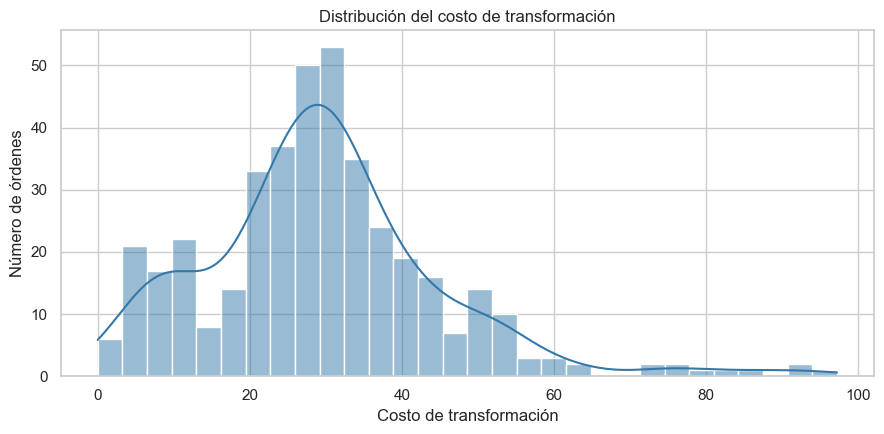

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(y, bins=30, kde=True, ax=ax, color="#3478a8")
ax.set(title="Distribución del costo de transformación", xlabel="Costo de transformación", ylabel="Número de órdenes")
plt.tight_layout()

**Conclusión del histograma.** La mayor concentración se encuentra en el tramo central, con una cola que se extiende hacia costos altos. La forma es compatible con la asimetría positiva resumida en la tabla; un único promedio describe de manera incompleta las órdenes de costo elevado. La densidad superpuesta es una herramienta exploratoria y no una estimación de una distribución generadora validada.

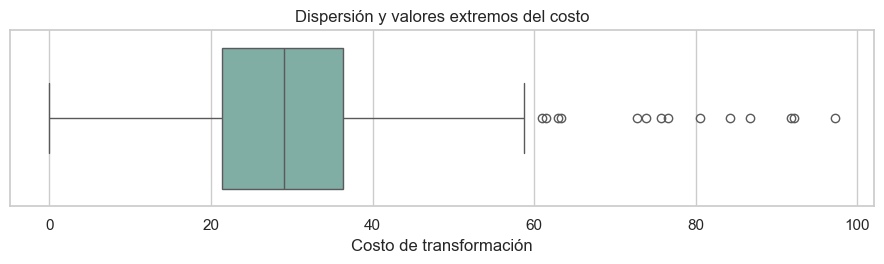

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.8))
sns.boxplot(x=y, ax=ax, color="#79b4a9")
ax.set(title="Dispersión y valores extremos del costo", xlabel="Costo de transformación")
plt.tight_layout()

**Conclusión del diagrama de caja.** La caja representa una dispersión intercuartílica amplia y la extensión hacia la derecha confirma la presencia de observaciones de costo alto. Los puntos que el criterio del diagrama marque como extremos son candidatos a revisión, no errores por definición; eliminarlos sin evidencia podría excluir condiciones operativas relevantes.

### 3.3 Asociaciones con predictores cuantitativos

In [7]:
variables_cuantitativas = [
    "costo_insumo", "duracion_proceso", "volumen_lote",
    "cantidad_insumo_1", "cantidad_insumo_2", "num_insumos",
]
variables_cuantitativas = [c for c in variables_cuantitativas if c in df.columns]
rho = df[[TARGET] + variables_cuantitativas].corr(method="spearman")[TARGET].drop(TARGET)
tabla_rho = (rho.rename("rho_de_Spearman")
             .to_frame()
             .assign(magnitud=lambda z: z["rho_de_Spearman"].abs())
             .sort_values("magnitud", ascending=False)
             .drop(columns="magnitud")
             .round(3))
display(tabla_rho)

,rho_de_Spearman
costo_insumo,0.385
duracion_proceso,0.292
num_insumos,0.291
cantidad_insumo_2,0.264
volumen_lote,-0.233
cantidad_insumo_1,0.060


**Interpretación de la tabla.** La asociación monotónica más alta corresponde a `costo_insumo` (ρ = 0,385), seguida de `duracion_proceso` (ρ = 0,292), el número de insumos (ρ = 0,291) y la cantidad del segundo insumo (ρ = 0,264). `volumen_lote` presenta una asociación negativa débil (ρ = −0,233), mientras que la cantidad del primer insumo tiene una asociación cercana a cero (ρ = 0,060). Ninguna relación marginal es fuerte. Spearman mide asociación ordinal, no controla por otras variables y no implica causalidad.

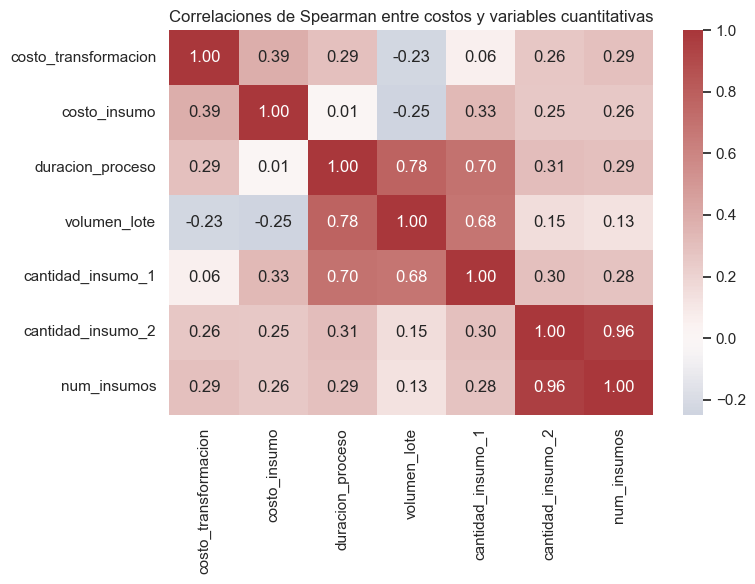

In [8]:
matriz = df[[TARGET] + variables_cuantitativas].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlaciones de Spearman entre costos y variables cuantitativas")
plt.tight_layout()

**Conclusión del mapa de calor.** La figura confirma el patrón de la tabla: las asociaciones de la respuesta con los predictores son moderadas o débiles. El costo de insumos y el tiempo de proceso aportan las señales monotónicas más claras, pero es razonable esperar que combinaciones entre escala, receta y equipo expliquen variación adicional. La matriz es simétrica; por ello, no constituye evidencia independiente a la tabla anterior.

C:\Users\Work\miniconda3\envs\project-env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


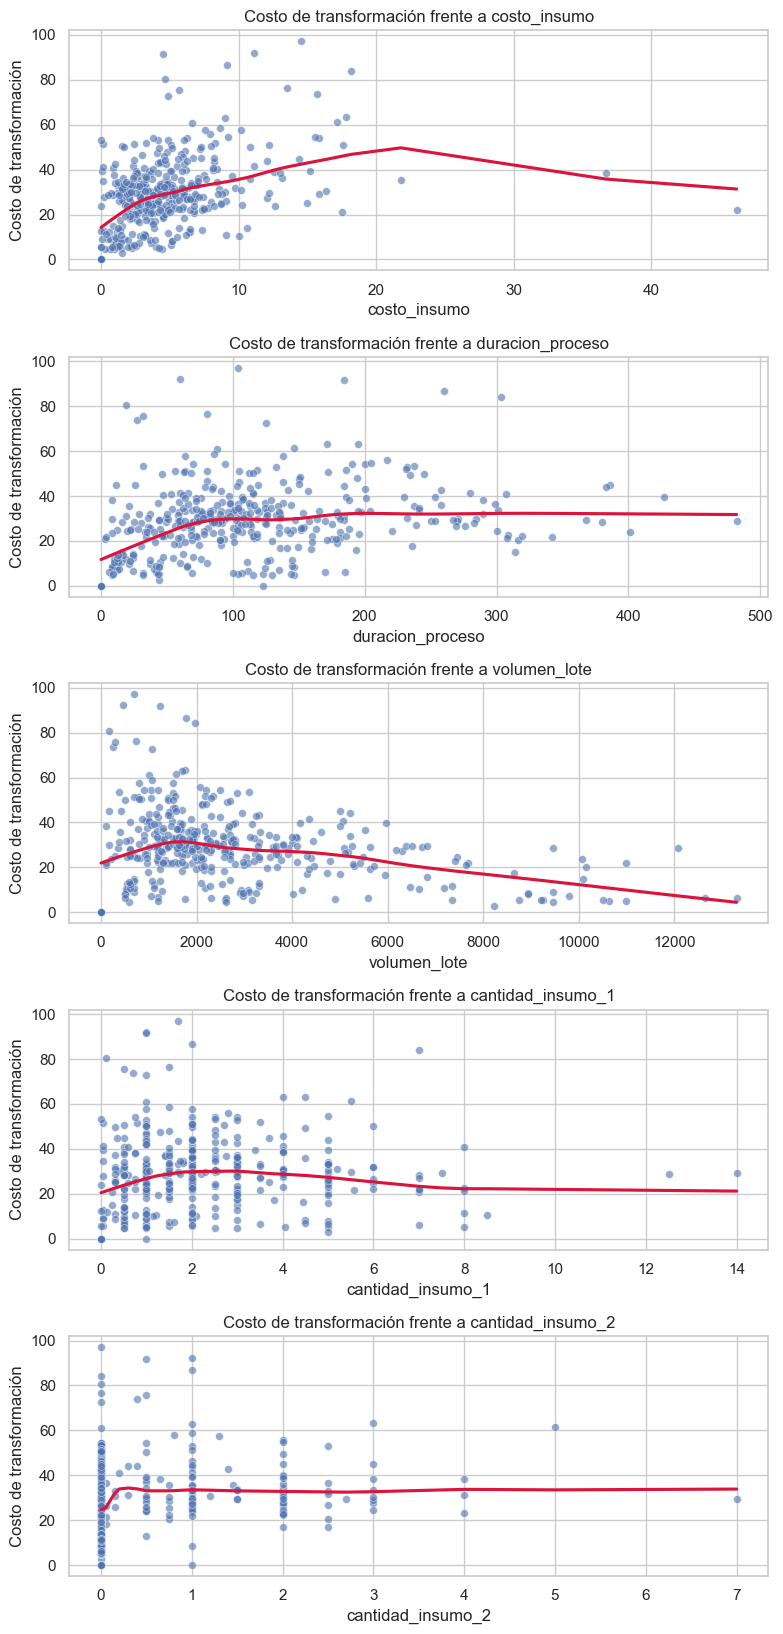

In [9]:
variables_graficos = [
    c for c in ["costo_insumo", "duracion_proceso", "volumen_lote", "cantidad_insumo_1", "cantidad_insumo_2"]
    if c in df.columns
]
fig, axes = plt.subplots(len(variables_graficos), 1, figsize=(8, 3.3 * len(variables_graficos)))
if len(variables_graficos) == 1:
    axes = [axes]
for ax, variable in zip(axes, variables_graficos):
    sns.scatterplot(data=df, x=variable, y=TARGET, alpha=.6, s=32, ax=ax)
    if df[variable].nunique() >= 10:
        sns.regplot(data=df, x=variable, y=TARGET, scatter=False, lowess=True, color="crimson", ax=ax)
    ax.set(title=f"Costo de transformación frente a {variable}", xlabel=variable, ylabel="Costo de transformación")
plt.tight_layout()

**Conclusiones de los diagramas de dispersión y curvas LOWESS.**

- **Costo de insumos:** la nube muestra una tendencia general ascendente, aunque con dispersión apreciable. Es la asociación bivariada más alta de las evaluadas; puede reflejar diferencias de receta o producto.
- **Duración:** la curva suavizada indica una tendencia global ascendente, sin que cada incremento de tiempo corresponda necesariamente al mismo cambio de costo.
- **Volumen del lote:** se observa una tendencia general descendente, compatible con economías de escala, pero el gráfico por sí solo no permite atribuir causalidad.
- **Cantidad del primer insumo:** la asociación es prácticamente nula en términos monotónicos; la variable no parece explicar por sí sola la variación del costo.
- **Cantidad del segundo insumo:** la relación es positiva pero débil y concentrada en órdenes con segundo insumo; el número de observaciones aplicables es menor que para las demás variables.

LOWESS ajusta regresiones locales para resumir la tendencia visual. La curva es sensible a la densidad de observaciones y no equivale a una función predictiva validada.

### 3.4 Heterogeneidad por equipo y configuración de producción

In [10]:
variables_grupo = ["tipo_equipo", "equipo_id", "modalidad_proceso", "num_insumos"]
filas = []
for variable in variables_grupo:
    tabla = df.groupby(variable, dropna=False)[TARGET].agg(n="count", media="mean", mediana="median", desv_std="std")
    for categoria, estadisticos in tabla.iterrows():
        filas.append({"variable": variable, "categoria": categoria, **estadisticos.to_dict()})
tabla_grupos = pd.DataFrame(filas).sort_values(["variable", "n"], ascending=[True, False])
display(tabla_grupos.round(2))

,variable,categoria,n,media,mediana,desv_std
14,equipo_id,M16,50.0,32.79,29.41,16.59
15,equipo_id,M17,46.0,29.71,29.43,11.81
4,equipo_id,M02,45.0,29.90,28.90,11.20
13,equipo_id,M15,44.0,37.15,34.95,12.97
12,equipo_id,M14,43.0,33.52,31.80,11.90
8,equipo_id,M09,41.0,32.54,28.82,16.56
11,equipo_id,M13,36.0,30.31,28.92,9.35
7,equipo_id,M08,35.0,30.38,29.09,10.59
6,equipo_id,M05,31.0,10.10,9.99,3.75
10,equipo_id,M12,25.0,7.10,6.35,2.41


**Interpretación de la tabla por grupos.** Se aprecian diferencias descriptivas considerables entre categorías. Por tipo de equipo, `D4` presenta una media de 8,76, mientras que `A1` y `B2` promedian 32,44 y 29,90; `C3` alcanza 64,36, pero solo cuenta con 8 órdenes. Entre equipos individuales, las medias también varían ampliamente (por ejemplo, `M12`: 7,10; `M15`: 37,15). La modalidad `Z` tiene una media de 41,62 (14 órdenes), frente a 27,60 para `X` y 30,78 para `Y`. El costo medio aumenta descriptivamente de 27,26 en órdenes con un insumo a 35,51 con dos; la categoría de cero insumos contiene solo 8 órdenes. Los tamaños pequeños exigen cautela y estas diferencias podrían estar confundidas por producto, volumen u otras condiciones.

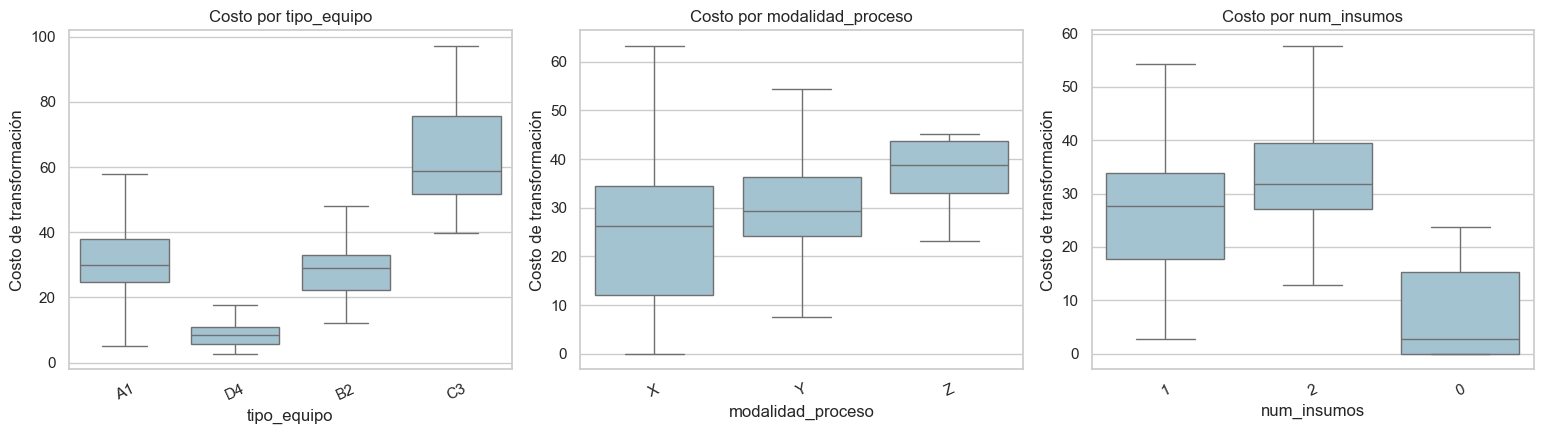

In [11]:
variables_caja = ["tipo_equipo", "modalidad_proceso", "num_insumos"]
fig, axes = plt.subplots(1, len(variables_caja), figsize=(5.2 * len(variables_caja), 4.5))
for ax, variable in zip(axes, variables_caja):
    orden = df[variable].value_counts().index
    sns.boxplot(data=df, x=variable, y=TARGET, order=orden, showfliers=False, ax=ax, color="#9bc6d9")
    ax.set(title=f"Costo por {variable}", xlabel=variable, ylabel="Costo de transformación")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

**Conclusión de los diagramas de caja por grupo.** El tipo de equipo y la modalidad muestran desplazamientos en la mediana y diferencias en la dispersión. También se observa una mediana mayor para órdenes con dos insumos que para órdenes con uno. Estos patrones respaldan evaluar interacciones o modelos estratificados; no prueban que cambiar de equipo, modalidad o receta produzca por sí mismo una reducción del costo. Se ocultaron los puntos fuera de los bigotes para facilitar la comparación, por lo que la figura no debe usarse para evaluar valores extremos.

### 3.5 Variación descriptiva entre periodos

In [12]:
mensual = df.assign(mes=pd.to_datetime(df["periodo"].astype(str), format="%Y%m", errors="coerce"))
mensual = mensual.groupby("mes", as_index=False).agg(
    ordenes=(TARGET, "size"),
    costo_medio=(TARGET, "mean"),
    costo_mediano=(TARGET, "median"),
)
display(mensual.round(2))

,mes,ordenes,costo_medio,costo_mediano
0,2025-01-01,35,32.04,32.91
1,2025-02-01,42,27.76,28.31
2,2025-03-01,20,35.23,29.38
3,2025-04-01,37,28.22,29.66
4,2025-05-01,19,28.91,27.63
5,2025-06-01,24,28.52,28.26
6,2025-07-01,23,31.11,31.21
7,2025-08-01,23,32.84,27.51
8,2025-09-01,16,32.65,30.13
9,2025-10-01,48,26.21,25.28


**Interpretación de la tabla mensual.** El número de órdenes cambia de 12 a 52 por periodo, por lo que la precisión de los promedios mensuales no es uniforme. Las medias y medianas difieren en algunos meses, reflejando sensibilidad a la cola superior. Estos valores describen el extracto y no deben interpretarse como evidencia de una tendencia estable.

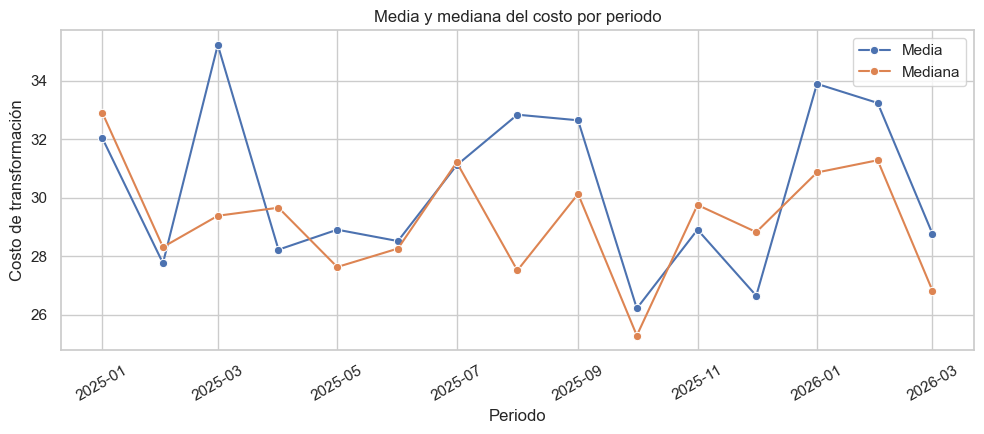

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=mensual, x="mes", y="costo_medio", marker="o", ax=ax, label="Media")
sns.lineplot(data=mensual, x="mes", y="costo_mediano", marker="o", ax=ax, label="Mediana")
ax.set(title="Media y mediana del costo por periodo", xlabel="Periodo", ylabel="Costo de transformación")
plt.xticks(rotation=30)
plt.tight_layout()

**Conclusión del gráfico mensual.** Las medidas fluctúan entre meses sin una trayectoria monótona sostenida durante los 15 periodos observados. La media presenta movimientos más pronunciados que la mediana en algunos meses, lo cual es coherente con la influencia de observaciones altas. Debido a los tamaños mensuales desiguales y al horizonte limitado, el gráfico es exploratorio; una evaluación destinada a predecir periodos futuros requeriría una partición cronológica específica.

## 4. Modelo base: regresión lineal Ridge

Se estandarizan las variables cuantitativas y se codifican las categóricas mediante indicadores; estos pasos se ajustan dentro de cada pliegue para evitar filtración de información. Se excluye `id_orden` por ser un identificador. La intensidad de regularización se selecciona con validación cruzada interna entre 17 valores de α.

Se reporta la media de las métricas por pliegue para (a) validación aleatoria repetida de 5 pliegues, con 3 repeticiones, y (b) validación agrupada por `codigo_producto` en 5 pliegues. En la segunda, los productos del pliegue de prueba no aparecen en el entrenamiento. El modelo de referencia predice la media del costo de entrenamiento en cada pliegue.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=[TARGET, "id_orden"]).copy()
y_modelo = pd.to_numeric(df[TARGET], errors="coerce")
categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
for columna in ["periodo", "categoria_producto"]:
    if columna in X.columns and columna not in categoricas:
        categoricas.append(columna)
numericas = [columna for columna in X.columns if columna not in categoricas]
X[categoricas] = X[categoricas].fillna("__AUSENTE__").astype(str)

preprocesamiento = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("estandarizar", StandardScaler()),
    ]), numericas),
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="__AUSENTE__")),
        ("indicadores", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas),
])

def evaluar_pliegues(iterador, nombre_validacion):
    resultados = []
    cv_interna = KFold(n_splits=3, shuffle=True, random_state=17)
    for pliegue, (idx_entrenamiento, idx_prueba) in enumerate(iterador, start=1):
        modelo = Pipeline([
            ("preprocesamiento", preprocesamiento),
            ("ridge", RidgeCV(
                alphas=np.logspace(-3, 5, 17),
                cv=cv_interna,
                scoring="neg_mean_squared_error",
            )),
        ])
        modelo.fit(X.iloc[idx_entrenamiento], y_modelo.iloc[idx_entrenamiento])
        prediccion = modelo.predict(X.iloc[idx_prueba])
        referencia = np.full(len(idx_prueba), y_modelo.iloc[idx_entrenamiento].mean())
        for nombre_modelo, y_estimado in [("Ridge", prediccion), ("Media de entrenamiento", referencia)]:
            resultados.append({
                "validacion": nombre_validacion,
                "pliegue": pliegue,
                "modelo": nombre_modelo,
                "RMSE": np.sqrt(mean_squared_error(y_modelo.iloc[idx_prueba], y_estimado)),
                "MAE": mean_absolute_error(y_modelo.iloc[idx_prueba], y_estimado),
                "R_cuadrado": r2_score(y_modelo.iloc[idx_prueba], y_estimado),
            })
    return resultados

cv_aleatoria = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
resultados_modelo = evaluar_pliegues(
    cv_aleatoria.split(X, y_modelo), "Aleatoria: 5 pliegues × 3 repeticiones"
)
cv_producto = GroupKFold(n_splits=5)
resultados_modelo += evaluar_pliegues(
    cv_producto.split(X, y_modelo, groups=df["codigo_producto"]),
    "Agrupada por producto: 5 pliegues",
)

resultados_modelo = pd.DataFrame(resultados_modelo)
tabla_modelo = (resultados_modelo
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .agg(["mean", "std"]).round(2))
display(tabla_modelo)

RMSE        \
                                                                mean   std   
validacion                             modelo                                
Agrupada por producto: 5 pliegues      Media de entrenamiento  15.63  2.24   
                                       Ridge                   10.54  1.05   
Aleatoria: 5 pliegues × 3 repeticiones Media de entrenamiento  15.55  1.18   
                                       Ridge                   10.05  1.36   

                                                                 MAE        \
                                                                mean   std   
validacion                             modelo                                
Agrupada por producto: 5 pliegues      Media de entrenamiento  11.33  2.23   
                                       Ridge                    7.42  0.53   
Aleatoria: 5 pliegues × 3 repeticiones Media de entrenamiento  11.19  1.01   
                                       Ridge                    6.52  0.70   

                                                              R_cuadrado        
                                                                    mean   std  
validacion                             modelo                                   
Agrupada por producto: 5 pliegues      Media de entrenamiento      -0.07  0.09  
                                       Ridge                        0.51  0.04  
Aleatoria: 5 pliegues × 3 repeticiones Media de entrenamiento      -0.02  0.02  
                                       Ridge                        0.57  0.09

**Interpretación de la tabla del modelo.** En validación aleatoria, Ridge obtiene RMSE medio de 10,05, MAE de 6,52 y R² medio de 0,57; el predictor basado en la media alcanza RMSE de 15,55 y MAE de 11,19. Al reservar productos completos, Ridge obtiene RMSE de 10,54, MAE de 7,42 y R² de 0,51, frente a RMSE de 15,63 y MAE de 11,33 para la referencia. Por tanto, Ridge mejora de forma consistente a la referencia, incluso cuando se evalúa en códigos de producto no vistos.

El desempeño es moderado, no perfecto: queda una fracción importante de variación sin explicar y los errores mantienen la unidad del costo. La diferencia relativamente pequeña entre partición aleatoria y agrupada sugiere que la señal no depende exclusivamente de repetir los mismos productos entre entrenamiento y prueba, aunque no demuestra transferencia a otras plantas ni a periodos futuros. Las desviaciones estándar de la tabla describen variación entre pliegues, no intervalos de confianza.

## 5. Conclusiones

1. El costo de transformación presenta heterogeneidad importante, asimetría positiva y cinco valores nulos que requieren validación de origen.
2. El costo de insumos, la duración del proceso y el número de insumos exhiben las asociaciones monotónicas positivas más altas; el volumen del lote se asocia negativamente, aunque ninguna correlación marginal es fuerte.
3. Las diferencias descriptivas por equipo y modalidad sugieren que el proceso no debe tratarse como completamente homogéneo. Las categorías con pocos registros deben interpretarse con cautela.
4. El modelo Ridge supera la referencia de media en validación aleatoria y agrupada por producto, con R² medio aproximado de 0,57 y 0,51, respectivamente. Es una línea base útil; se recomienda compararlo con modelos no lineales regularizados mediante el mismo diseño de validación.

El análisis es exploratorio y depende de la calidad, definición operativa y representatividad de las variables registradas. Las asociaciones observadas no permiten atribuir efectos causales.